# Finding vulnerabilities in the masked Decompose fonction of Dilithium

Given the dataset provided by Notebook "0_building_datasets.ipynb", this notebook performs and displays the ANOVA and build the template.

## Preliminaries
---

In [1]:
!pwd

/media/sf_vm_shared/Dev/ML-DSA/Security/Decompose/artifacts/artifacts/clean_template


In [2]:
# Loading auxiliary functions 
probable_path_to_helpers_functions = !find ../Common_functions -name "Helpers.py"

# If the Helper.py file is not found and you don't need it, comment this cell
# If the Helper.py file is not found and you need it, something went wrong ...
print(f"Probable path to Helpers functions:")
print(f">>> {probable_path_to_helpers_functions}")
probable_path_to_helpers_functions = probable_path_to_helpers_functions[0]

%run -i $probable_path_to_helpers_functions

Probable path to Helpers functions:
>>> ['../Common_functions/Helpers.py']


In [3]:
# Importing useful libraries
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from tqdm.notebook import trange
import copy

import scared
import estraces

from collections import Counter

from scalib.preprocessing import Quantizer
from scalib.metrics import Ttest, SNR

import struct 

from scipy.signal import correlate
from scipy.ndimage import shift

In [4]:
# Setting default size of figures in Matplotlib
plt.rcParams["figure.figsize"] = (13,3) 

# Set the maximum display width for NumPy arrays
np.set_printoptions(linewidth=sys.maxsize)

# Adjusting the display of tables
np.set_printoptions(threshold=sys.maxsize)

In [5]:
# Matplotlib constants 
span_color = "#FFC069"
color0 = "darkblue"
color1 = "coral"

## Charging datasets


In [6]:
dataset = f'dataset__dcp2__rdm.ets'
ths = estraces.read_ths_from_ets_file(dataset)
ths

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file dataset__dcp2__rdm.ets with 22623 traces.
w................: uint8
w_share0.........: uint8
w_share1.........: uint8
w_z2.............: uint8
w_z3.............: uint8

In [7]:
ths.samples.shape

(22623, 20000)

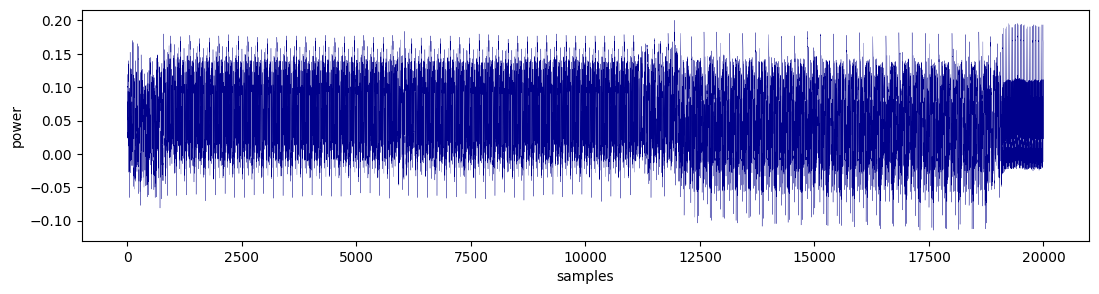

In [8]:
plt.plot(ths.samples[:1].T,color=color0,linewidth=0.2)
plt.xlabel("samples")
plt.ylabel("power")
plt.savefig("trace_complete", bbox_inches='tight')
plt.show()

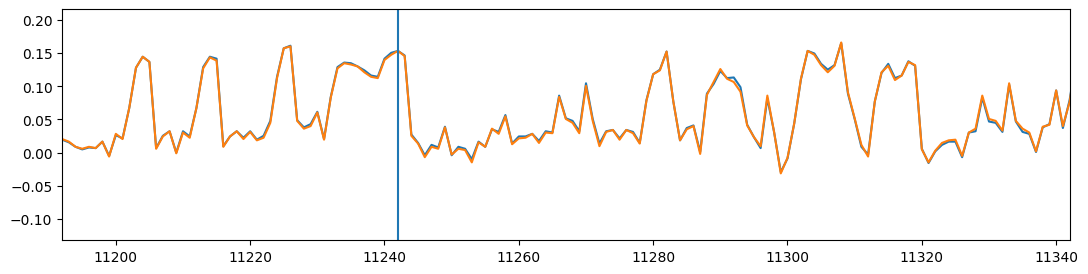

In [9]:
plt.plot(ths.samples[:2].T)
plt.plot(ths.samples[50000:50010].T)
plt.xlim(11242-50, 11242+100)
plt.axvline(x=11242)
plt.show()

### Aligning traces

In [10]:
def align_traces(data, window_center, window_size, max_shift):
    """
    Aligns traces in a large array based on cross-correlation within a specific window.
    
    Parameters:
    - data: np.array of shape (N_traces, N_samples)
    - window_center: int, index of the feature to align on (approximate)
    - window_size: int, width of the window to use for correlation
    - max_shift: int, maximum expected shift (to limit search)
    
    Returns:
    - aligned_data: np.array, the realigned traces
    - shifts: np.array, the integer shifts applied to each trace
    """
    n_traces, n_samples = data.shape
    
    # 1. Define Reference (using the mean can be more robust than using just data[0])
    # However, for speed on large data, we can just use the first trace if it's clean.
    ref_trace = np.median(data, axis=0) # Median is robust to outliers
    
    # Define the Region of Interest (ROI) for the reference
    start = max(0, window_center - window_size // 2)
    end = min(n_samples, window_center + window_size // 2)
    ref_window = ref_trace[start:end]
    
    # Pre-allocate output
    aligned_data = np.zeros_like(data)
    shifts = np.zeros(n_traces, dtype=int)
    
    # 2. Iterate and Calculate Lags
    # Note: We loop because vectorizing cross-corr on different lags is tricky.
    # Given the window is small, this loop will be fast enough.
    
    for i in range(n_traces):
        # Extract the same window from the current trace
        # We widen the search window by 'max_shift' to ensure we catch the feature
        search_start = max(0, start - max_shift)
        search_end = min(n_samples, end + max_shift)
        
        curr_window = data[i, search_start:search_end]
        
        # Cross-correlate
        # 'valid' mode means we slide the smaller ref_window over the larger curr_window
        xcorr = correlate(curr_window, ref_window, mode='valid')
        
        # Find the index of maximum correlation
        # The peak in xcorr corresponds to the best alignment position
        best_idx = np.argmax(xcorr)
        
        # Calculate the shift relative to the center
        # The logic depends on 'valid' correlation output size
        # Expected peak index if aligned is 'max_shift'
        shift_amount = best_idx - max_shift
        
        shifts[i] = shift_amount
        
        # 3. Apply Shift
        # Integers shifts are faster using np.roll, but it wraps around. 
        # For valid signal data, we usually want to fill with 0s or NaNs.
        # Custom roll with padding:
        if shift_amount == 0:
            aligned_data[i] = data[i]
        elif shift_amount > 0: # Trace is delayed, shift left (negative roll) or right?
            # If shift is positive, it means the trace appears LATER than ref.
            # We need to shift it LEFT (negative index) to align.
            # However, let's stick to standard convention: shift value is how much to move trace.
            
            # Using simple roll (circular buffer) - fast
            aligned_data[i] = np.roll(data[i], -shift_amount)
            # Zero out the wrapped part if necessary
            aligned_data[i, -shift_amount:] = 0
            
        else: # shift_amount < 0
            aligned_data[i] = np.roll(data[i], -shift_amount)
            aligned_data[i, :-shift_amount] = 0

    return aligned_data, shifts

# --- Usage Example ---

# 1. Setup Dummy Data (64k traces, 20k samples)
# NOTE: This generates random data, usually you load your real .npy file
# For testing, we use a smaller size, but the logic holds.
# N_TRACES = 64000
# N_SAMPLES = 20000
# data = np.load("your_data.npy") 

# 2. Define Parameters
# You need to know roughly where your signal is.
# Example: If you have a pulse at index 5000
offset_location = 5000 
window_width = 400       # Look at 400 samples around the pulse
max_expected_shift = 50  # We expect shifts no larger than +/- 50 samples

batched = 7541
for i in trange(ths.samples.shape[0]//batched, desc="Resynchro traces"):
    aligned_traces, _ = align_traces(ths.samples[(i)*batched: (i+1)*batched], 11242, 25, 25)
    if i == 0:
        alll = copy.deepcopy(aligned_traces[:, 11242-50: 11242+800])
    else:
        alll = np.concatenate((alll, aligned_traces[:, 11242-50: 11242+800]))

ths_synchro = estraces.read_ths_from_ram(alll, w = ths.w, w_share0 = ths.w_share0, w_share1 = ths.w_share1, w_z2 =ths.w_z2, w_z3 =ths.w_z3)

ths_synchro

Resynchro traces:   0%|          | 0/3 [00:00<?, ?it/s]

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 22623 traces. Samples shape: (22623, 850) and metadatas: ['w', 'w_share0', 'w_share1', 'w_z2', 'w_z3']
w................: uint8
w_share0.........: uint8
w_share1.........: uint8
w_z2.............: uint8
w_z3.............: uint8

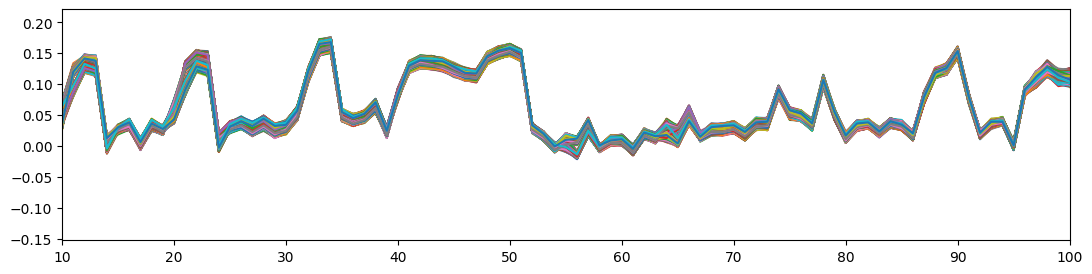

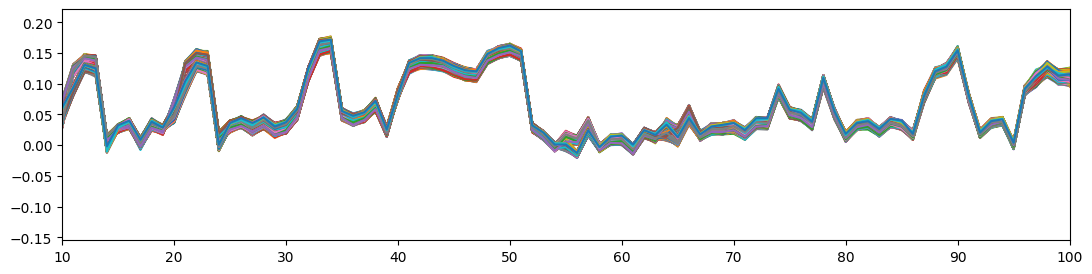

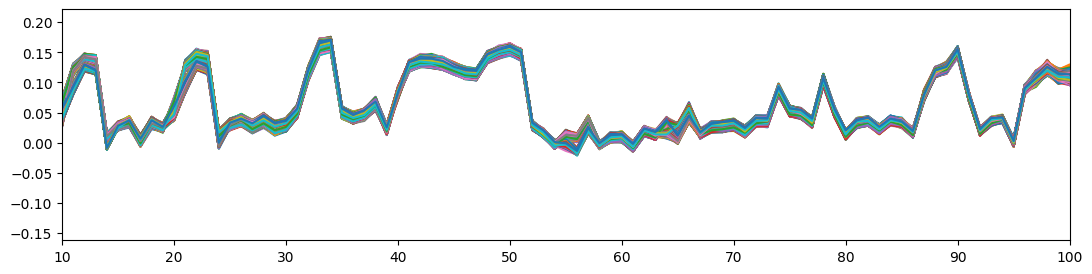

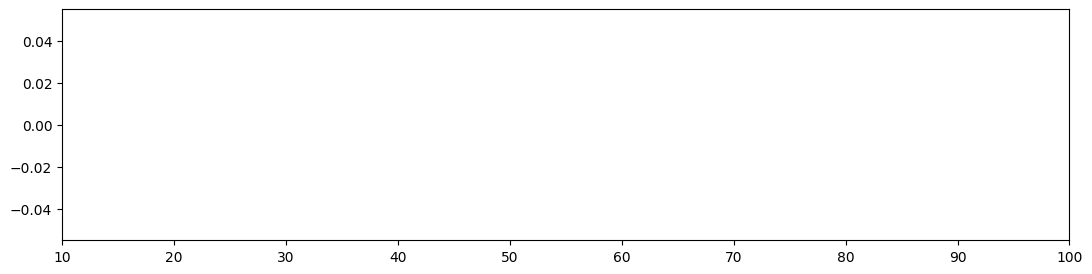

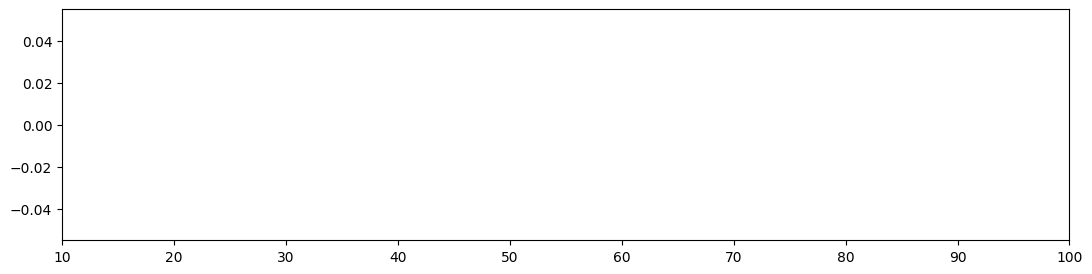

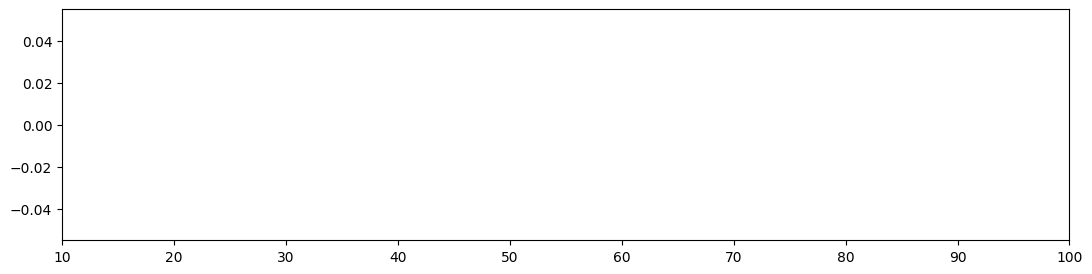

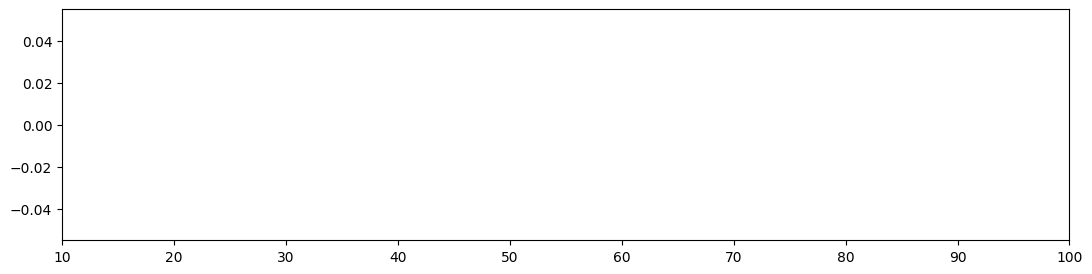

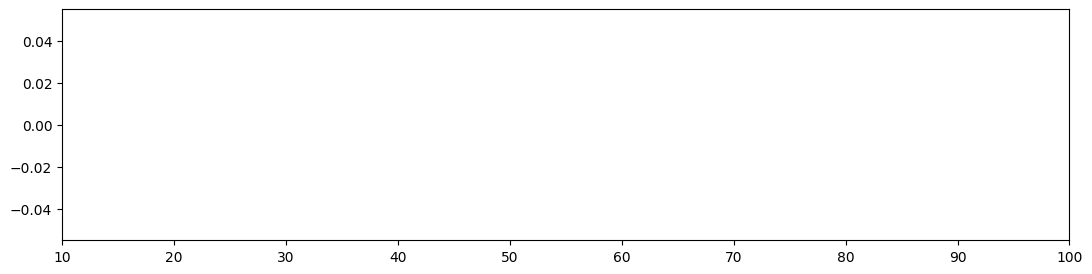

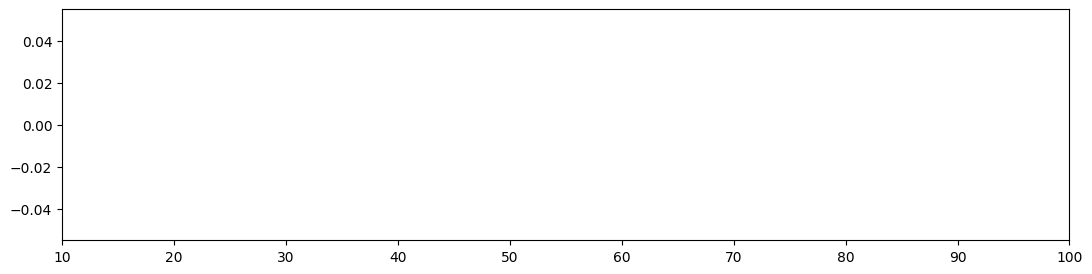

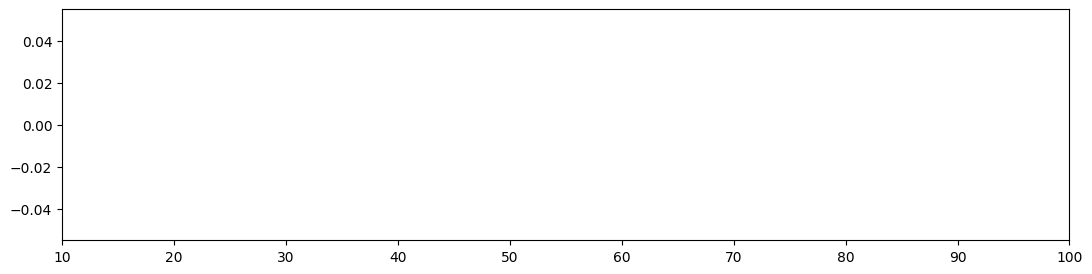

In [11]:
for i in range(10):
    plt.plot(ths_synchro.samples[(i)*batched: (i+1)*batched].T)
    plt.xlim(10, 100)
    plt.show()

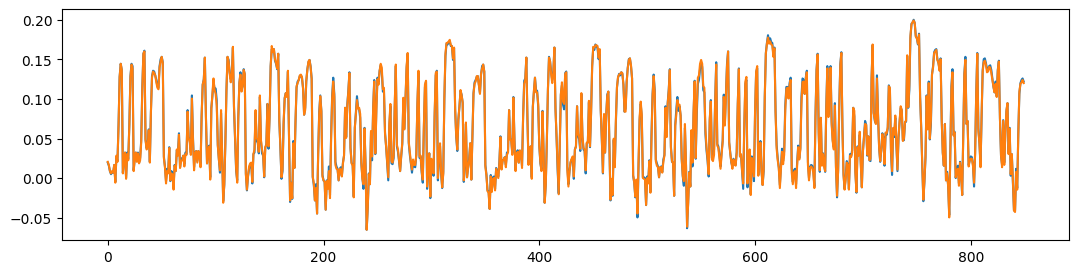

In [12]:
plt.plot(ths_synchro.samples[:2].T)
plt.plot(ths_synchro.samples[50000:50010].T)
plt.show()

## Saving synchronized traces

In [13]:
ets_synchro = estraces.ETSWriter(f'dataset_synchro.ets', overwrite = True)

ets_synchro.add_trace_header_set(ths_synchro)

ets_synchro.close()

--------

## Statistical Analysis

In [11]:
dataset = f'dataset_synchro.ets'
ths_synchro = estraces.read_ths_from_ets_file(dataset)
ths_synchro

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file dataset_synchro.ets with 22623 traces.
w................: uint8
w_share0.........: uint8
w_share1.........: uint8
w_z2.............: uint8
w_z3.............: uint8

In [12]:
ths_synchro.w_z2

array([[  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [255, 255, 122,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [255, 223, 127,   0],
       [ 16,  39,  95,   0],
       [ 47, 235, 125,   0],
       [  0,   0,   0,   0],
       [255, 211, 123,   0],
       [184,  62,  62,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [  0,   0,   0,   0],
       [127, 255,  57,   0],
       [191, 153, 103,   0],
       [221, 255, 101,   0],
       [  0,   0,   0,   0],
       [ 61, 171, 127,   0],
       [  0,   0,   0,   0],
       [ 57,  94, 127,   0],
       [  0,  

### ANOVA

- For ML-DSA 2 choose  `K = 2`
- For ML-DSA 3 choose  `K = 3`
- For ML-DSA 5 choose  `K = 5`

In [22]:
MODE = 2
# K = 3
# K = 5

In [23]:
# Loading ml-dsa parameters according to the chosen security level K
%run -i ../Common_functions/MLDSA_parameters.py {MODE}

# Loading auxiliary functions
%run -i ../Common_functions/MLDSA_functions.py

# Loading auxiliary functions
%run -i ../Common_functions/Additional_functions.py

In [24]:
def hw(string):
    return string.count("1")

v__hw = np.vectorize(hw)

def compute_hw_recombined_z2(w, w_share0, w_share1):
    return v__hw(np.vectorize(np.binary_repr)((Q-44)*np.uint32(w.view(dtype='<u4')).view('int32') +(Q-1)//2, width=32))

def compute_hw_z2(w, w_share0, w_share1, w_z2, w_z3):
    return v__hw(np.vectorize(np.binary_repr)(w_z2.view(dtype='<u4'), width=32))

def compute_hw_z3(w, w_share0, w_share1, w_z2, w_z3):
    return v__hw(np.vectorize(np.binary_repr)(w_z3.view(dtype='<u4'), width=32))

In [25]:
ths_synchro

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file dataset_synchro.ets with 22623 traces.
w................: uint8
w_share0.........: uint8
w_share1.........: uint8
w_z2.............: uint8
w_z3.............: uint8

In [26]:
S = scared.reverse_selection_function(function = compute_hw_z2)

In [27]:
ReverseANOVA = scared.ANOVAReverse(selection_function=S,
                                 model = scared.Value(),
                                )

In [28]:
container = scared.Container(ths_synchro)

In [29]:
ReverseANOVA.run(container)

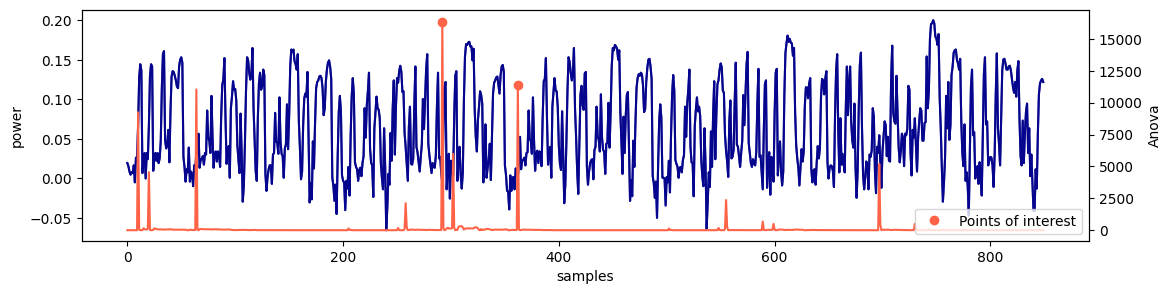

In [30]:
fg, ax = plt.subplots(1, 1)
 
plt.plot(ths_synchro.samples[:1].T, color = color0, alpha=0.85)
ax.plot(ths_synchro.samples[:1].T, color = color0, alpha=0.85)
ax2 = ax.twinx()
plt.plot(ReverseANOVA.results[0, :ths_synchro.samples[0].shape[0]], color = "tomato", alpha = 1)
ax.set_xlabel("samples")
ax.set_ylabel("power")
ax2.set_ylabel("Anova")
ax2.plot(292,16300,"o",color="tomato",label = "Points of interest")
ax2.plot(362,11400,"o",color="tomato")
plt.legend(loc = "lower right")
plt.savefig("Anova",bbox_inches='tight')
plt.show()

In [39]:
pois = np.sort(np.argsort(ReverseANOVA.results[0])[-2:])
pois

array([292, 362])

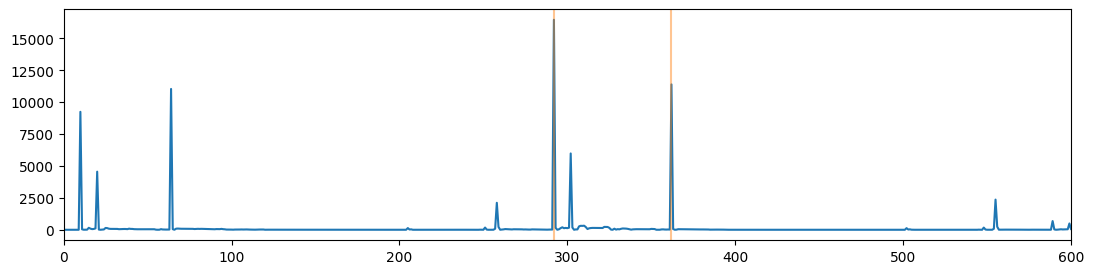

In [41]:
plt.plot(ReverseANOVA.results[0])
for i in range(len(pois)):
    plt.axvline(pois[i], color = "C1", alpha = 0.45)
plt.xlim(0, 600)
plt.show()   

In [42]:
TAttacks = scared.TemplateAttack(container_building = scared.Container(ths_synchro, frame = pois),
                                   reverse_selection_function = scared.reverse_selection_function(function = compute_hw_z2),
                                  model = scared.Value(),
                                  convergence_step = 1,
                                   partitions = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]))

In [43]:
TAttacks.build()

In [44]:
colors = [
    '#00438f', '#064a92', '#0d5094', '#145696', '#1a5d99', 
    '#1f649c', '#246b9e', '#2872a0', '#2d79a3', '#3281a4', 
    '#3689a6', '#3b91a8', '#4099a9', '#4a9fa6', '#53a4a4', 
    '#5caaa2', '#66b09f', '#6fb48b', '#78b976', '#81be62', 
    '#8ac24e', '#94c64e', '#9fcb4e', '#aad04f', '#b4d44f', 
    '#bfcf49', '#caca42', '#d5c53c', '#e0c036', '#dbaa28', 
    '#d6931b', '#d17c0e', '#cc6600'
]

ref = 0

In [48]:
a = np.save("./drawing_nathan/templates.npy",TAttacks.templates)
b = np.save("./drawing_nathan/partitions.npy",TAttacks.partitions)

In [49]:
pois

array([292, 362])

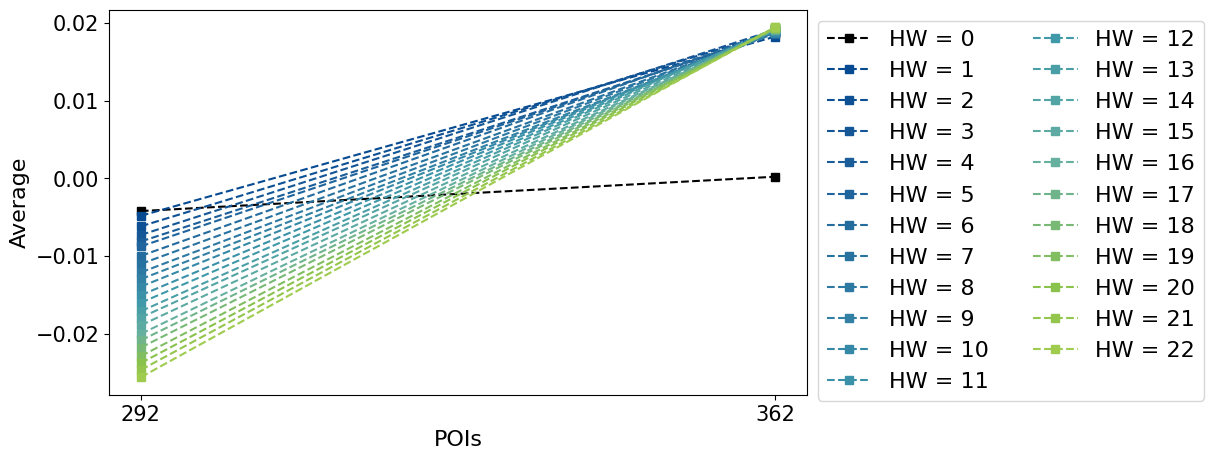

In [45]:

color_backup = copy.deepcopy(colors[ref])
colors[ref] = "#000000"
fg, ax = plt.subplots(figsize = (9, 5))
templates = TAttacks.templates
for hw_ in range(len(TAttacks.partitions)):
    ax.plot(templates[hw_], "--s", color= colors[TAttacks.partitions[hw_]], label = f"HW = {TAttacks.partitions[hw_]}")
    # ax.scatter([i for i in range(5)], templates[hw_], marker="s", color= colors[TAttacks[byte_i].partitions[hw_]], label = f"HW = {TAttacks[byte_i].partitions[hw_]}")
# plt.title(f"Moyennes pour le byte {byte_i}")
plt.xticks(np.arange(0, len(pois)))
ax.set_xlabel("POIs", fontsize = 16)
ax.set_ylabel("Average", fontsize = 16)
ax.tick_params(axis='both', which='major', labelsize=15)
labels = [item.get_text() for item in ax.get_xticklabels()]
for i in range(len(labels)):
    labels[i] = str(pois[i])
ax.set_xticklabels(labels)
plt.legend(prop={'size': 16}, loc="upper left", bbox_to_anchor=(1, 1), ncol=2)
colors[ref] = color_backup
plt.savefig("template_res",bbox_inches='tight')